In [1]:


import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import logit

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts

# Time-series
from prophet import Prophet          # uncomment if installed
from pmdarima import auto_arima      # uncomment if installed

#Geo (optional — comment out if geopandas not installed)
import geopandas as gpd
import folium

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})


In [2]:
import pandas as pd
df = pd.read_csv("df_clean.csv")

# ════════════════════════════════════════════════════════════════════════════════
# CELL 4.1 — Treatment Outcomes: WHO standard outcomes, success rate
# ════════════════════════════════════════════════════════════════════════════════


SECTION 4.1 — TREATMENT OUTCOMES (WHO)

 Treatment Outcomes (All Cases):


,Outcome,Cases,%
0,Unknown,3860,45.2
1,Cured,2636,30.9
2,Completed,1397,16.4
3,Died,404,4.7
4,Lost To Follow-Up,164,1.9
5,Not Evaluated,51,0.6
6,Failure,28,0.3


Treatment success rate (Cured + Completed): 30.9%
Based on 'outcome_success' flag: 2,636 (30.9%)


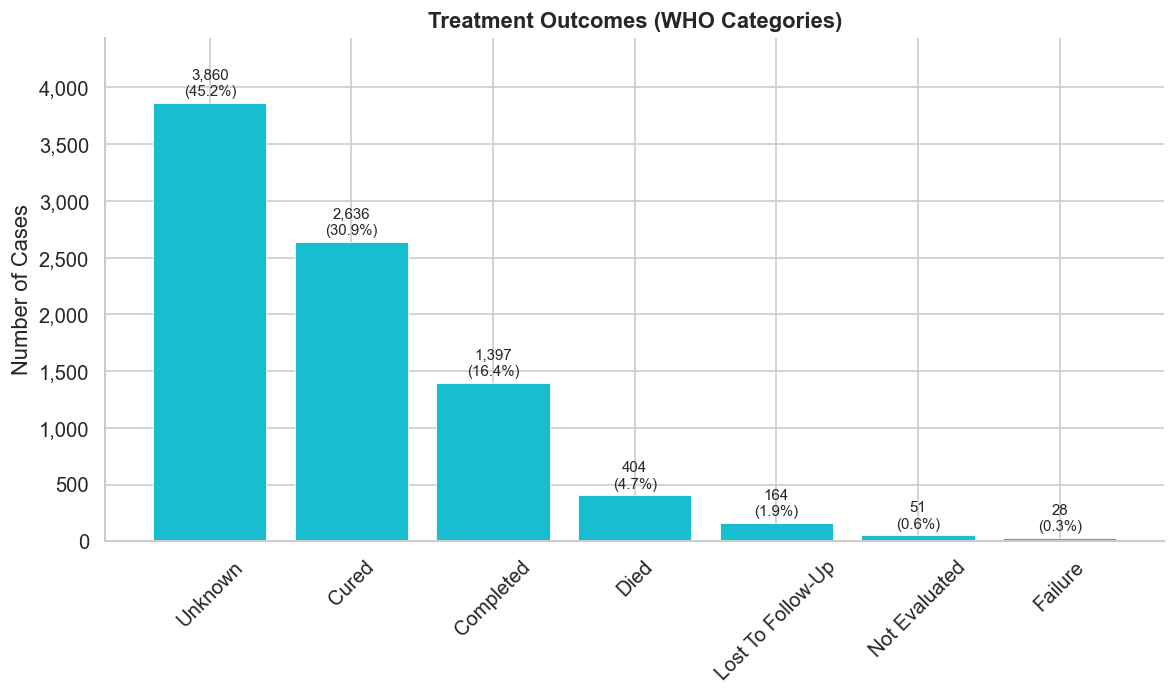

In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 4.1 — Treatment Outcomes: WHO standard outcomes, success rate
# ════════════════════════════════════════════════════════════════════════════════

# Define colors (if not already defined in earlier cells)
BLUE = "#1f77b4"
CORAL = "#ff7f50"
TEAL = "#17becf"
AMBER = "#ffbb78"
PURPLE = "#9467bd"
GREEN = "#2ca02c"

print("\n" + "="*70)
print("SECTION 4.1 — TREATMENT OUTCOMES (WHO)")
print("="*70)

if 'treatment_outcome' in df.columns:
    # Clean outcome column: strip whitespace, convert to title case for consistency
    df['treatment_outcome_clean'] = df['treatment_outcome'].astype(str).str.strip().str.title()
    # Replace empty strings with NaN
    df['treatment_outcome_clean'] = df['treatment_outcome_clean'].replace(['', 'Nan', 'None'], pd.NA)

    # Count outcomes (excluding NaN)
    outcome_counts = df['treatment_outcome_clean'].value_counts(dropna=False).reset_index()
    outcome_counts.columns = ['Outcome', 'Cases']
    outcome_counts['Cases'] = outcome_counts['Cases'].astype(int)
    outcome_counts['%'] = (outcome_counts['Cases'] / len(df) * 100).round(1)

    # Define success categories: Cured and Treatment Completed
    success_keywords = ['Cured', 'Treatment Completed']
    # Mask to identify successful outcomes
    success_mask = outcome_counts['Outcome'].astype(str).str.contains('|'.join(success_keywords), case=False, na=False)
    cured_completed = outcome_counts[success_mask]['Cases'].sum()
    success_rate = (cured_completed / len(df) * 100).round(1)

    print("\n Treatment Outcomes (All Cases):")
    display(outcome_counts)
    print(f"Treatment success rate (Cured + Completed): {success_rate}%")

    # If an 'outcome_success' flag exists, cross‑check (optional)
    if 'outcome_success' in df.columns:
        flag_success = df['outcome_success'].sum()
        flag_rate = (flag_success / len(df) * 100).round(1)
        print(f"Based on 'outcome_success' flag: {flag_success:,} ({flag_rate}%)")

    # Plot outcome distribution (order by descending cases)
    fig, ax = plt.subplots(figsize=(10, 6))
    outcome_sorted = outcome_counts.sort_values('Cases', ascending=False)
    bars = ax.bar(outcome_sorted['Outcome'], outcome_sorted['Cases'],
                  color=TEAL, edgecolor='white', linewidth=0.5)
    for bar, pct in zip(bars, outcome_sorted['%']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + outcome_sorted['Cases'].max()*0.01,
                f"{int(bar.get_height()):,}\n({pct}%)",
                ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, outcome_sorted['Cases'].max() * 1.15)
    ax.set_title('Treatment Outcomes (WHO Categories)', fontweight='bold')
    ax.set_ylabel('Number of Cases')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine()
    plt.tight_layout()
    plt.savefig('fig_4_1_treatment_outcomes.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Column 'treatment_outcome' not found. Skipping treatment outcomes.")

# ════════════════════════════════════════════════════════════════════════════════
# CELL 4.2 — Subgroup Analysis of Treatment Outcomes
# ════════════════════════════════════════════════════════════════════════════════



▶ Treatment Success Rate by District:


,Total,Success,Success_%
district,,,
Rwamagana District,771,352,45.7
Musanze District,274,125,45.6
Muhanga District,408,174,42.6
Kirehe District,206,83,40.3
Gisagara District,238,94,39.5
Karongi District,198,77,38.9
Kayonza District,214,82,38.3
Ngoma District,173,66,38.2
Rutsiro District,103,37,35.9


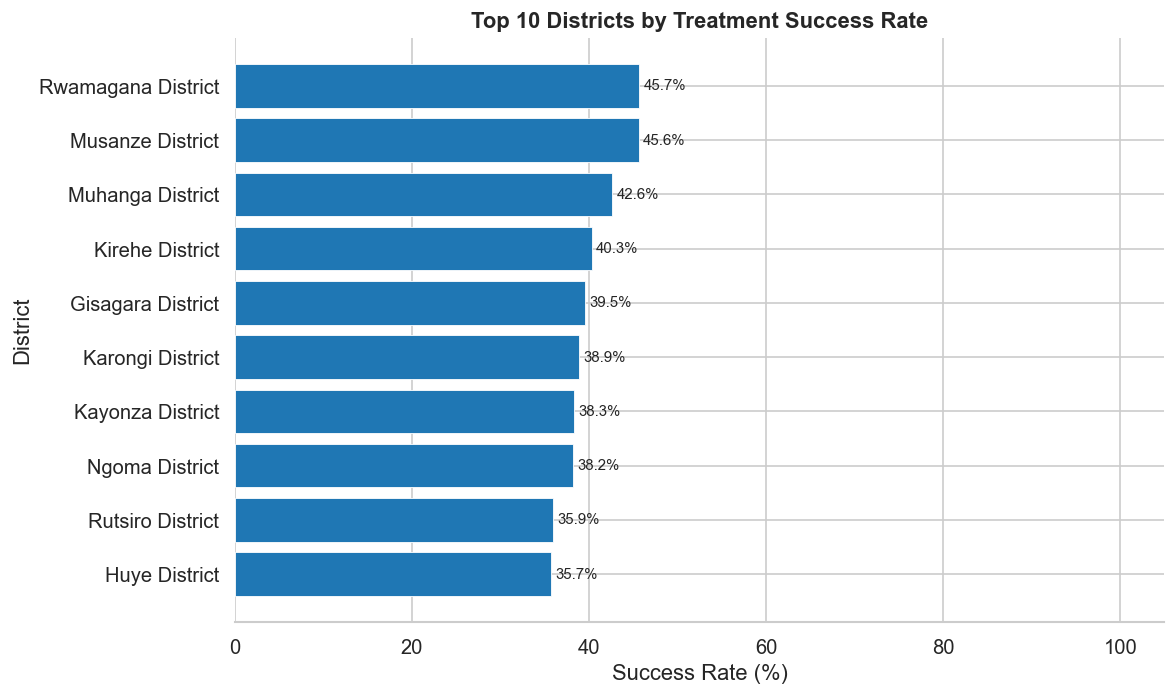


▶ Treatment Success Rate by Age Group:


,Total,Success,Success_%
age_group,,,
15–24,1130,411,36.4
35–44,1951,667,34.2
25–34,1992,680,34.1
45–54,1056,355,33.6
55–64,862,264,30.6
65+,791,217,27.4
5–14,145,25,17.2
0–4,613,17,2.8


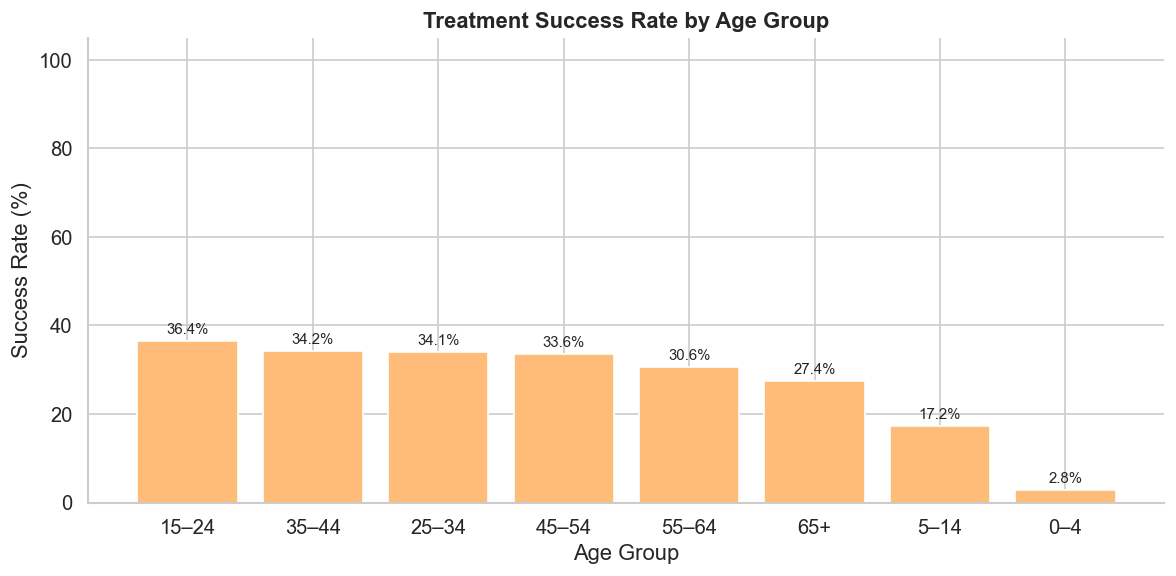


▶ Treatment Success Rate by Sex:


,Total,Success,Success_%
sex,,,
Unknown,1,1,100.0
Male,6278,2045,32.6
Female,2261,590,26.1


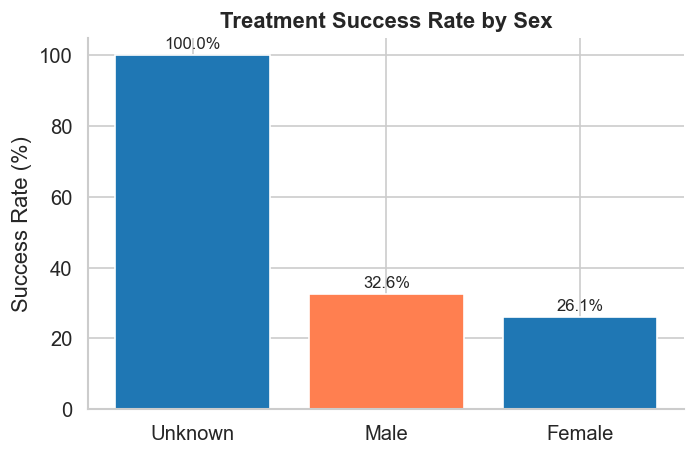


▶ Treatment Success Rate by TB Type (Top 10):


,Total,Success,Success_%
tb_type,,,
Unknown,7282,2628,36.1
Genitourinary TB,38,3,7.9
Lymphadenitis,160,3,1.9
Miliary TB,113,1,0.9
Pleural TB,545,1,0.2
Breast TB,2,0,0.0
Cutaneous TB,28,0,0.0
Gastrointestinal TB,20,0,0.0
Adrenal Glands,2,0,0.0



▶ Treatment Success Rate by Drug Sensitivity:


,Total,Success,Success_%
ds_dr_group,,,


No DS/DR categories found in 'drug_sensitivity'.


In [12]:

if 'treatment_outcome_clean' in df.columns:
    # Define success categories (if not already defined)
    success_keywords = ['Cured', 'Treatment Completed']

    # Helper to compute success rate for subgroups
    def success_rate_by_group(group_series, df):
        success_mask = df['treatment_outcome_clean'].str.contains('|'.join(success_keywords), case=False, na=False)
        success_by_group = df[success_mask].groupby(group_series).size()
        total_by_group = df.groupby(group_series).size()
        success_rate_df = pd.DataFrame({
            'Total': total_by_group,
            'Success': success_by_group.reindex(total_by_group.index, fill_value=0)
        })
        success_rate_df['Success_%'] = (success_rate_df['Success'] / success_rate_df['Total'] * 100).round(1)
        return success_rate_df.sort_values('Success_%', ascending=False)

    # 1. By district
    if 'district' in df.columns:
        district_success = success_rate_by_group('district', df)
        print("\n▶ Treatment Success Rate by District:")
        display(district_success.head(15))

        # Horizontal bar chart (top 10 districts by success rate)
        top10_dist_success = district_success.head(10).copy()
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(top10_dist_success.index[::-1], top10_dist_success['Success_%'][::-1],
                       color=BLUE, edgecolor='white', linewidth=0.5)
        for bar, rate in zip(bars, top10_dist_success['Success_%'][::-1]):
            ax.text(bar.get_width() + 0.5,
                    bar.get_y() + bar.get_height()/2,
                    f"{rate}%", va='center', ha='left', fontsize=9)
        ax.set_xlim(0, 105)
        ax.set_title('Top 10 Districts by Treatment Success Rate', fontweight='bold')
        ax.set_xlabel('Success Rate (%)')
        ax.set_ylabel('District')
        sns.despine(left=True)
        plt.tight_layout()
        plt.savefig('fig_4_2_success_by_district.png', bbox_inches='tight', dpi=150)
        plt.show()

    # 2. By age group
    if 'age_group' in df.columns:
        age_success = success_rate_by_group('age_group', df)
        print("\n▶ Treatment Success Rate by Age Group:")
        display(age_success)

        # Bar chart
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(age_success.index, age_success['Success_%'], color=AMBER, edgecolor='white')
        for bar, rate in zip(bars, age_success['Success_%']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{rate}%", ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, 105)
        ax.set_title('Treatment Success Rate by Age Group', fontweight='bold')
        ax.set_xlabel('Age Group')
        ax.set_ylabel('Success Rate (%)')
        sns.despine()
        plt.tight_layout()
        plt.savefig('fig_4_2_success_by_age.png', bbox_inches='tight', dpi=150)
        plt.show()

    # 3. By sex
    if 'sex' in df.columns:
        sex_success = success_rate_by_group('sex', df)
        print("\n▶ Treatment Success Rate by Sex:")
        display(sex_success)

        # Bar chart
        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(sex_success.index, sex_success['Success_%'], color=[BLUE, CORAL], edgecolor='white')
        for bar, rate in zip(bars, sex_success['Success_%']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{rate}%", ha='center', va='bottom', fontsize=10)
        ax.set_ylim(0, 105)
        ax.set_title('Treatment Success Rate by Sex', fontweight='bold')
        ax.set_ylabel('Success Rate (%)')
        sns.despine()
        plt.tight_layout()
        plt.savefig('fig_4_2_success_by_sex.png', bbox_inches='tight', dpi=150)
        plt.show()

    # 4. By TB type (pulmonary vs extra-pulmonary)
    if 'tb_type' in df.columns:
        tbtype_success = success_rate_by_group('tb_type', df)
        print("\n▶ Treatment Success Rate by TB Type (Top 10):")
        display(tbtype_success.head(10))

    # 5. By drug sensitivity (DS vs DR) – using 'drug_sensitivity' column
    if 'drug_sensitivity' in df.columns:
        # Simplify into DS-TB vs DR-TB
        ds_keywords = ['DS', 'drug-susceptible', 'susceptible', 'DS-TB', 'sensitive']
        dr_keywords = ['DR', 'drug-resistant', 'resistant', 'MDR', 'XDR', 'RR', 'mono', 'poly']
        df['ds_dr_group'] = 'Other'
        for kw in ds_keywords:
            df.loc[df['drug_sensitivity'].str.lower().str.contains(kw, na=False), 'ds_dr_group'] = 'DS-TB'
        for kw in dr_keywords:
            df.loc[df['drug_sensitivity'].str.lower().str.contains(kw, na=False), 'ds_dr_group'] = 'DR-TB'

        dsdr_success = success_rate_by_group('ds_dr_group', df)
        # Filter only DS and DR groups
        dsdr_success = dsdr_success[dsdr_success.index.isin(['DS-TB', 'DR-TB'])]
        print("\n▶ Treatment Success Rate by Drug Sensitivity:")
        display(dsdr_success)

        # Bar chart
        if not dsdr_success.empty:
            fig, ax = plt.subplots(figsize=(6, 4))
            bars = ax.bar(dsdr_success.index, dsdr_success['Success_%'], color=[TEAL, CORAL], edgecolor='white')
            for bar, rate in zip(bars, dsdr_success['Success_%']):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f"{rate}%", ha='center', va='bottom', fontsize=10)
            ax.set_ylim(0, 105)
            ax.set_title('Treatment Success: DS-TB vs DR-TB', fontweight='bold')
            ax.set_ylabel('Success Rate (%)')
            sns.despine()
            plt.tight_layout()
            plt.savefig('fig_4_2_success_by_drug_sensitivity.png', bbox_inches='tight', dpi=150)
            plt.show()
        else:
            print("No DS/DR categories found in 'drug_sensitivity'.")

else:
    print("Treatment outcome data not available. Skipping subgroup analysis.")


▶ Treatment Success Rate by Sex (excluding unknown):


,Total,Success,Success_%
sex,,,
Male,6278,2045,32.6
Female,2261,590,26.1


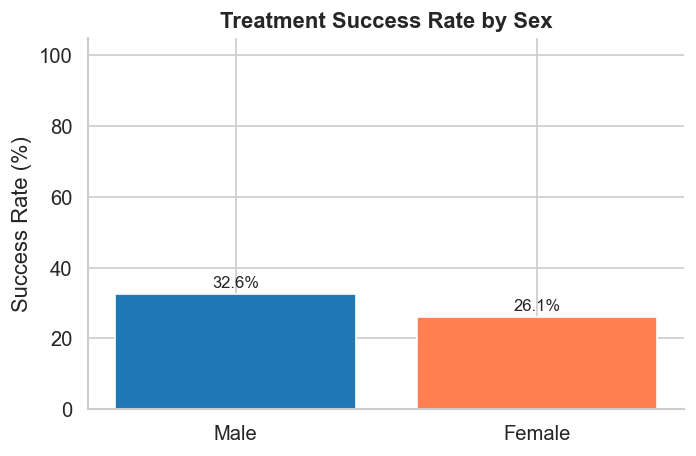

In [13]:
if 'sex' in df.columns:
    # Exclude rows where sex is 'Unknown' or missing (also handle NaN)
    sex_filtered = df[df['sex'].notna() & (df['sex'].str.upper() != 'UNKNOWN')]
    sex_success = success_rate_by_group('sex', sex_filtered)   # use filtered DataFrame
    print("\n▶ Treatment Success Rate by Sex (excluding unknown):")
    display(sex_success)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(sex_success.index, sex_success['Success_%'],
                  color=[BLUE, CORAL], edgecolor='white')
    for bar, rate in zip(bars, sex_success['Success_%']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{rate}%", ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_title('Treatment Success Rate by Sex', fontweight='bold')
    ax.set_ylabel('Success Rate (%)')
    sns.despine()
    plt.tight_layout()
    plt.savefig('fig_4_2_success_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()


▶ Treatment Outcome Distribution by Sex (Counts):


sex,Female,Male,Unknown,Total
treatment_outcome_clean,,,,
Completed,424,973,0,1397
Cured,590,2045,1,2636
Died,134,270,0,404
Failure,6,22,0,28
Lost To Follow-Up,46,118,0,164
Not Evaluated,22,29,0,51
Unknown,1039,2821,0,3860
Total,2261,6278,1,8540



▶ Treatment Outcome Distribution by Sex (Column %):


sex,Female,Male,Unknown,Total
treatment_outcome_clean,,,,
Completed,18.8,15.5,0.0,34.3
Cured,26.1,32.6,100.0,158.7
Died,5.9,4.3,0.0,10.2
Failure,0.3,0.4,0.0,0.6
Lost To Follow-Up,2.0,1.9,0.0,3.9
Not Evaluated,1.0,0.5,0.0,1.4
Unknown,46.0,44.9,0.0,90.9


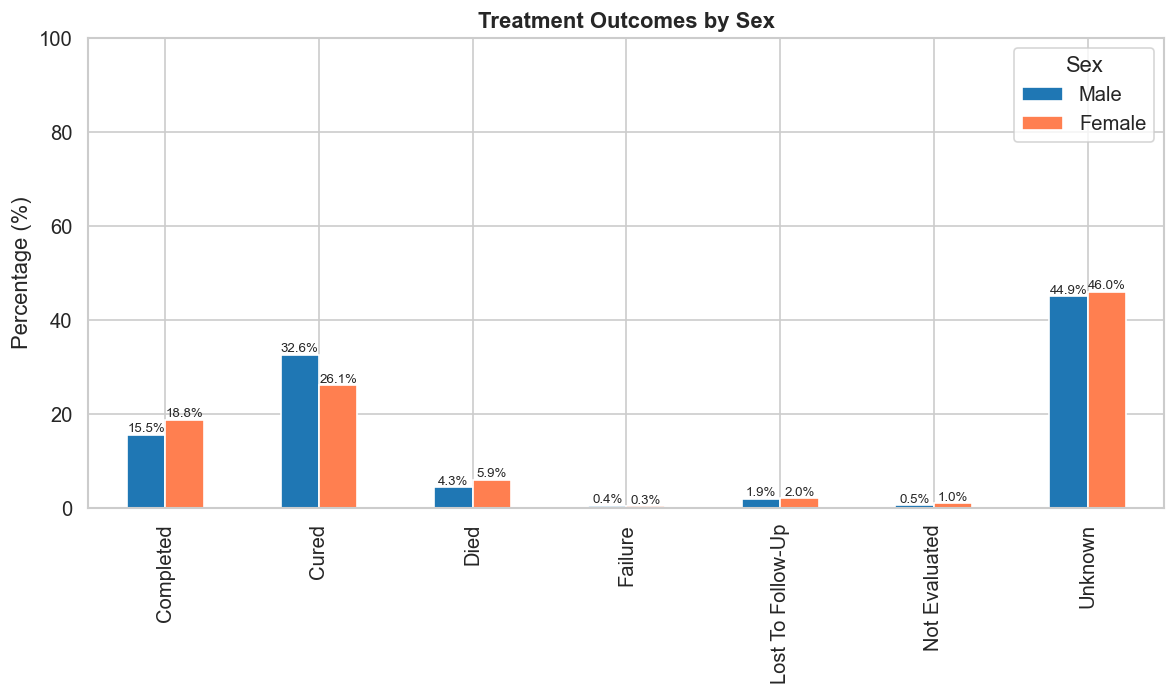

In [14]:
if 'treatment_outcome_clean' in df.columns and 'sex' in df.columns:
    # Exclude unknown sex if you want, but keep for completeness
    # Create a cross‑tabulation of outcome by sex
    outcome_by_sex = pd.crosstab(df['treatment_outcome_clean'], df['sex'], margins=True, margins_name='Total')
    print("\n▶ Treatment Outcome Distribution by Sex (Counts):")
    display(outcome_by_sex)

    # For percentages within each sex (column percentages)
    outcome_by_sex_pct = pd.crosstab(df['treatment_outcome_clean'], df['sex'], normalize='columns') * 100
    # Add a row for total
    outcome_by_sex_pct['Total'] = outcome_by_sex_pct.sum(axis=1)
    print("\n▶ Treatment Outcome Distribution by Sex (Column %):")
    display(outcome_by_sex_pct.round(1))

    # Optional: bar chart for males and females
    # Filter to remove 'Total' row for plotting
    plot_data = outcome_by_sex_pct.drop(index='Total', errors='ignore')
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_data[['Male', 'Female']].plot(kind='bar', ax=ax, color=[BLUE, CORAL])
    ax.set_title('Treatment Outcomes by Sex', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.legend(title='Sex')
    ax.set_ylim(0, 100)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8)
    plt.tight_layout()
    plt.savefig('fig_4_2_outcomes_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Required columns not found.")

In [16]:
if 'date_treatment_start' in df.columns and 'treatment_outcome_clean' in df.columns:
    # Convert start date to datetime
    df['start_dt'] = pd.to_datetime(df['date_treatment_start'], errors='coerce')
    latest_date = df['start_dt'].max()
    cutoff = latest_date - pd.DateOffset(months=6)
    print(f"Latest treatment start date: {latest_date}")
    print(f"Cutoff (6 months before latest): {cutoff}")

    # Create a new outcome category
    df['outcome_final'] = df['treatment_outcome_clean'].copy()
    unknown_mask = df['outcome_final'].str.lower().str.contains('unknown', na=False) | df['outcome_final'].isna()
    total_unknown = unknown_mask.sum()
    print(f"Total unknown outcomes before recoding: {total_unknown} ({total_unknown/len(df)*100:.1f}%)")

    # For unknowns that started within the last 6 months -> "On treatment"
    recent_start = (df['start_dt'] >= cutoff) & unknown_mask
    df.loc[recent_start, 'outcome_final'] = 'On treatment'
    print(f"Of those, started within last 6 months: {recent_start.sum()} → recoded as 'On treatment'")

    # The remaining unknowns are truly missing
    remaining_unknown = unknown_mask & ~recent_start
    df.loc[remaining_unknown, 'outcome_final'] = 'Missing'
    print(f"Remaining missing after recoding: {remaining_unknown.sum()}")

    # Show new outcome distribution
    print("\nUpdated outcome categories:")
    print(df['outcome_final'].value_counts(dropna=False))

    # Optional: update the original treatment_outcome_clean for consistency
    # df['treatment_outcome_clean'] = df['outcome_final']  # uncomment if you want to replace
else:
    print("Required columns missing or not prepared.")

Latest treatment start date: 2024-05-18 00:00:00
Cutoff (6 months before latest): 2023-11-18 00:00:00
Total unknown outcomes before recoding: 3860 (45.2%)
Of those, started within last 6 months: 745 → recoded as 'On treatment'
Remaining missing after recoding: 3115

Updated outcome categories:
outcome_final
Missing              3115
Cured                2636
Completed            1397
On treatment          745
Died                  404
Lost To Follow-Up     164
Not Evaluated          51
Failure                28
Name: count, dtype: int64


Data quality concern: Over one‑third of records lack a documented outcome, suggesting incomplete follow‑up or data entry gaps. This limits the reliability of program performance metrics.

# ════════════════════════════════════════════════════════════════════════════════
# CELL 5.1 — Diagnostic Cascade
# ════════════════════════════════════════════════════════════════════════════════


SECTION 5.1 — DIAGNOSTIC CASCADE

▶ Diagnostic Delay (days from symptom onset to diagnosis):


count    779.000000
mean       1.178434
std        7.448037
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      131.000000
Name: diag_delay_days, dtype: float64

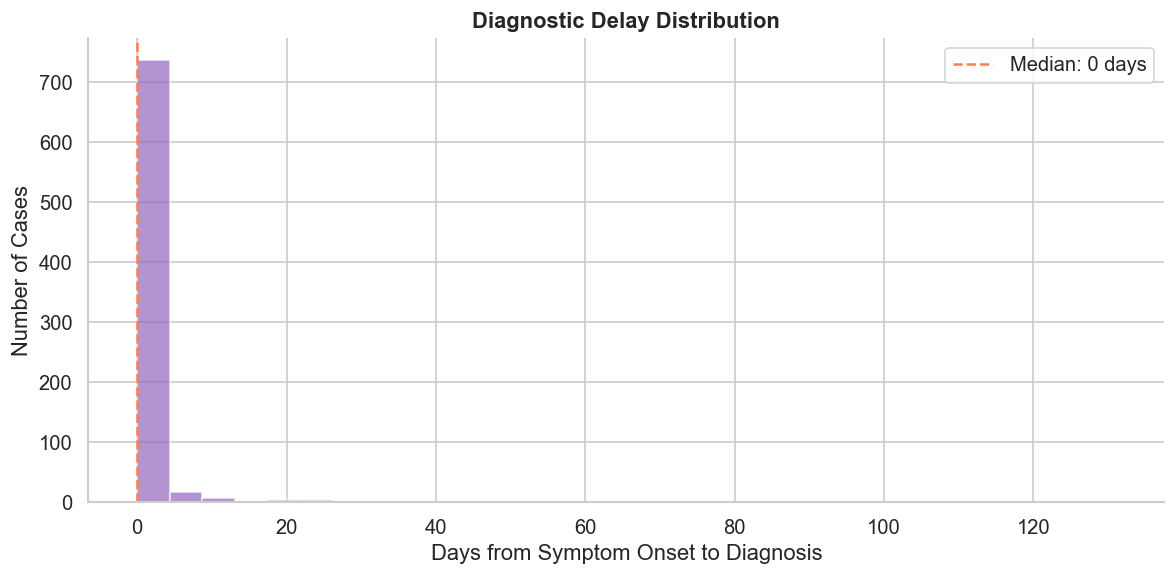


▶ Diagnostic Cascade Summary:


,Step,Count
0,Total TB Cases,8540
1,Bacteriologically Confirmed,6196
2,Tested (any method),8540
3,Xpert Positive,6494
4,Smear Positive,1385
5,Culture Positive,35
6,TB LAM Positive,56


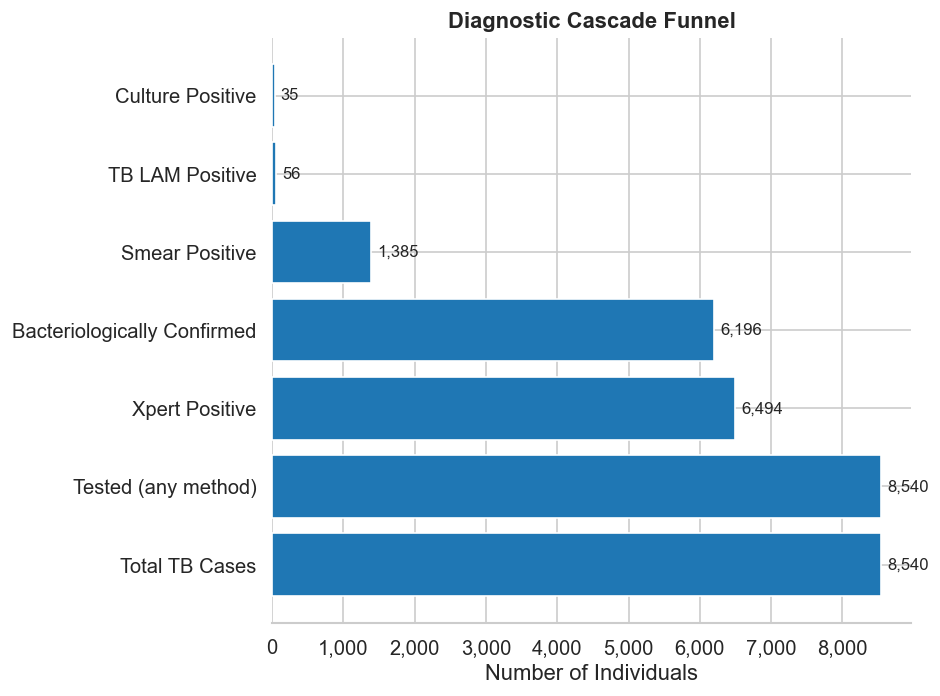

In [20]:

print("SECTION 5.1 — DIAGNOSTIC CASCADE")

# Define colors (if not already defined)
BLUE = "#1f77b4"
CORAL = "#ff7f50"
PURPLE = "#9467bd"
TEAL = "#17becf"

# Dictionary to hold cascade steps
cascade_data = {}

# 1. Total TB cases (all rows)
cascade_data['Total TB Cases'] = len(df)

# 2. Bacteriologically confirmed – using 'bact_confirmed' column with text values
if 'bact_confirmed' in df.columns:
    # Convert to string, lower case, and count those containing 'bacteriologically'
    bact_confirmed = df['bact_confirmed'].astype(str).str.lower().str.contains('bacteriologically', na=False).sum()
    cascade_data['Bacteriologically Confirmed'] = bact_confirmed

# 3. Tested by any method (if any test result column exists)
test_cols = ['xpert_result', 'smear_result', 'culture_result', 'tb_lam_result']
tested_cols = [c for c in test_cols if c in df.columns]
if tested_cols:
    # At least one test result non‑null
    tested = df[tested_cols].notna().any(axis=1).sum()
    cascade_data['Tested (any method)'] = tested

# 4. Xpert positive
if 'xpert_result' in df.columns:
    xpert_pos = df[df['xpert_result'].astype(str).str.lower().str.contains('detected|positive', na=False)].shape[0]
    cascade_data['Xpert Positive'] = xpert_pos

# 5. Smear positive
if 'smear_result' in df.columns:
    smear_pos = df[df['smear_result'].astype(str).str.lower().str.contains('positive|\\+', na=False)].shape[0]
    cascade_data['Smear Positive'] = smear_pos

# 6. Culture positive
if 'culture_result' in df.columns:
    culture_pos = df[df['culture_result'].astype(str).str.lower().str.contains('positive|\\+', na=False)].shape[0]
    cascade_data['Culture Positive'] = culture_pos

# 7. TB LAM positive
if 'tb_lam_result' in df.columns:
    lam_pos = df[df['tb_lam_result'].astype(str).str.lower().str.contains('positive|detected', na=False)].shape[0]
    cascade_data['TB LAM Positive'] = lam_pos

# 8. Diagnostic delay (using existing diag_delay_days column)
if 'diag_delay_days' in df.columns:
    diag_delay = pd.to_numeric(df['diag_delay_days'], errors='coerce')
    diag_delay_clean = diag_delay.dropna()
    if len(diag_delay_clean) > 0:
        delay_stats = diag_delay_clean.describe(percentiles=[0.25, 0.5, 0.75])
        print("\n▶ Diagnostic Delay (days from symptom onset to diagnosis):")
        display(delay_stats)

        # Histogram
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.hist(diag_delay_clean, bins=30, color=PURPLE, edgecolor='white', alpha=0.7)
        ax.axvline(diag_delay_clean.median(), color=CORAL, linestyle='--',
                   label=f"Median: {diag_delay_clean.median():.0f} days")
        ax.set_title('Diagnostic Delay Distribution', fontweight='bold')
        ax.set_xlabel('Days from Symptom Onset to Diagnosis')
        ax.set_ylabel('Number of Cases')
        ax.legend()
        sns.despine()
        plt.tight_layout()
        plt.savefig('fig_5_1_diagnostic_delay.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print("No valid diagnostic delay data available.")
else:
    print("Column 'diag_delay_days' not found; skipping delay analysis.")

# Print cascade summary
print("\n▶ Diagnostic Cascade Summary:")
cascade_df = pd.DataFrame(list(cascade_data.items()), columns=['Step', 'Count'])
if not cascade_df.empty:
    display(cascade_df)
else:
    print("No cascade steps available.")

# Create a funnel plot if we have at least two steps
if len(cascade_df) >= 2:
    # Order steps from largest to smallest
    cascade_df_sorted = cascade_df.sort_values('Count', ascending=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(cascade_df_sorted['Step'], cascade_df_sorted['Count'],
                   color=BLUE, edgecolor='white')
    for bar, count in zip(bars, cascade_df_sorted['Count']):
        ax.text(bar.get_width() + cascade_df_sorted['Count'].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f"{int(count):,}", va='center', ha='left', fontsize=10)
    ax.set_title('Diagnostic Cascade Funnel', fontweight='bold')
    ax.set_xlabel('Number of Individuals')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(left=True)
    plt.tight_layout()
    plt.savefig('fig_5_1_diagnostic_cascade.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Not enough cascade steps to plot.")

In [18]:
print(df['bact_confirmed'].value_counts(dropna=False))

bact_confirmed
Bacteriologically confirmed    6196
Clinically diagnosed           2344
Name: count, dtype: int64
